In [1]:
import mitsuba as mi
import drjit as dr
import matplotlib.pyplot as plt
import matplotlib as mpl
import sionna.rt as rt
import numpy as np

In [2]:
# from Anshul's notebook
mat_lunar_highland = rt.RadioMaterial(
    name="lunar-highland",
    thickness=11,
    relative_permittivity=2.7,
    conductivity=10**(-12.5),
    scattering_coefficient=0.4,
    xpd_coefficient=0.1,
    scattering_pattern='lambertian',
    frequency_update_callback=None,
    color=None,
    props=None)

mat_lunar_mare = rt.RadioMaterial(
    name="lunar-mare",
    thickness=5,
    relative_permittivity=2.7,
    conductivity=10**(-12.5),
    scattering_coefficient=0.4,
    xpd_coefficient=0.1,
    scattering_pattern='lambertian',
    frequency_update_callback=None,
    color=None,
    props=None)

In [3]:
def default_array(num_rows: int = 1, num_cols: int = 1,
                  vertical_spacing: float = 0.5, horizontal_spacing: float = 0.5,
                  pattern: str = "iso", polarization: str = "V"):
    return rt.PlanarArray(num_rows=num_rows,
                       num_cols=num_cols,
                       vertical_spacing=vertical_spacing,
                       horizontal_spacing=horizontal_spacing,
                       pattern=pattern,
                       polarization=polarization)

In [4]:
from sionna.rt import Scene, RadioMaterial, HolderMaterial, PlanarArray, Transmitter

N = 100
vert_x, vert_y = np.meshgrid(
    np.linspace(0, 10, N),
    np.linspace(0, 10, N),
    indexing="xy")
vert_z = (np.sin(2 * vert_x) + np.sin(2 * vert_y)) / 2
vert_xyz = np.stack([vert_x, vert_y, vert_z], axis=2).reshape(-1, 3)

# Triangulate
vertex_indices = np.arange(N * N)
is_last_column = (vertex_indices + 1) % N == 0
is_last_row = vertex_indices // N == N - 1
ii = vertex_indices[~is_last_row & ~is_last_column]
faces = np.stack([[ii, ii + 1, ii + N + 1], [ii, ii + N + 1, ii + N]])
faces = np.concatenate(faces.T, axis=-1).T

# Create scene
props = mi.Properties()
props["material"] = mat_lunar_highland
# props["material"] = rt.ITURadioMaterial("mat", itu_type="concrete", thickness=10)
# props["material"] = RadioMaterial("mat", thickness=10, relative_permittivity=100)
# Sionna requires bsdfs to be wrapped in HolderMaterial
props["material"] = HolderMaterial(props)
mi_mesh = mi.Mesh(name="terrain",
                    vertex_count=vert_xyz.shape[0],
                    face_count=faces.shape[0], 
                    props=props)
mi_mesh_params = mi.traverse(mi_mesh)
mi_mesh_params["vertex_positions"] = mi.Float(vert_xyz.ravel().astype(np.float32))
mi_mesh_params["faces"] = mi.UInt(faces.ravel().astype(np.uint32))
mi_mesh_params.update()
mi_scene = mi.load_dict({
    "type": "scene",
    "terrain": mi_mesh
})

scene = Scene(mi_scene)
scene.tx_array = default_array()
scene.rx_array = default_array(polarization="VH")
tx = Transmitter(name="tx",
                 position=mi.Point3f(0, 0, 1),
                 orientation=mi.Point3f(0,0,0),
                 power_dbm=100)
scene.add(tx)

In [5]:
# M = 35
# vert_x, vert_y = np.meshgrid(
#     np.linspace(0, 10, M),
#     np.linspace(0, 10, M),
#     indexing="xy")
# vert_z = (np.sin(2 * vert_x) + np.sin(2 * vert_y)) / 2
# vert_xyz = np.stack([vert_x, vert_y, vert_z], axis=2).reshape(-1, 3)

# # Triangulate
# vertex_indices = np.arange(M * M)
# is_last_column = (vertex_indices + 1) % M == 0
# is_last_row = vertex_indices // M == M - 1
# ii = vertex_indices[~is_last_row & ~is_last_column]
# faces = np.stack([[ii, ii + 1, ii + M + 1], [ii, ii + M + 1, ii + M]])
# faces = np.concatenate(faces.T, axis=-1).T

# meas_surf = mi.Mesh(name="terrain",
#                     vertex_count=vert_xyz.shape[0],
#                     face_count=faces.shape[0])
# mi_mesh_params = mi.traverse(meas_surf)
# mi_mesh_params["vertex_positions"] = mi.Float(vert_xyz.ravel().astype(np.float32))
# mi_mesh_params["faces"] = mi.UInt(faces.ravel().astype(np.uint32))
# mi_mesh_params.update()
# rt.transform_mesh(meas_surf, translation=[0, 0, 0.01])
terrain = scene.get("terrain")
meas_surf = terrain.clone(name="measurement_surface")
rt.transform_mesh(meas_surf.mi_mesh, translation=[0, 0, 0.01])

In [6]:
def paths_to_gains(paths):
    """
    Converts paths into the equivalent coverage map values.
    The coverage map is assumed to be a ssquare.
    """
    # [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
    a_real, a_imag = paths.a
    a = a_real.numpy() + 1j*a_imag.numpy()

    # Transmit precoding
    # Assume default precoding
    # [num_rx, num_rx_ant, num_tx, num_paths]
    a /= np.sqrt(a.shape[3])
    a = np.sum(a, axis=3)

    # Sum energy of paths
    a = np.square(np.abs(a))
    # [num_rx, num_tx]
    a = np.sum(a, axis=(1, 3))

    # Swap dims
    # [num_tx, num_rx]
    a = a.T

    return a

In [7]:
specular_reflection = True
diffuse_reflection = True
refraction=True 
max_depth = 5
los = True

In [8]:
# # Create the radio map, just for cell centers
rm_solver = rt.RadioMapSolver()
rm_solver.loop_mode = "evaluated"
rm = rm_solver(scene,
            measurement_surface=meas_surf,
            samples_per_tx=int(1e7),
            max_depth=max_depth,
            los=los,
            specular_reflection=specular_reflection,
            diffuse_reflection=diffuse_reflection,
            refraction=refraction)

# Check for NaN or Inf
assert not (dr.any(dr.isinf(rm.path_gain)) or dr.any(dr.isnan(rm.path_gain)))

In [9]:
# Add receivers at the cell centers
for i, pos in enumerate(rm.cell_centers.numpy().T):
    scene.remove(f"rx-{i}")
    scene.add(rt.Receiver(name=f"rx-{i}",
                        position=pos,
                        display_radius=0.1,
                        orientation=mi.Point3f(0, 0, 0)))

In [10]:
from time import perf_counter

max_depths = np.arange(6)
res: dict[str, list[rt.RadioMap]] = {"shoot_and_bounce": [], "antenna_pairs": []}
rm_solver = rt.RadioMapSolver()

# for some reason drjit implodes if I try to wrap this in a python for loop
def block(max_depth):
    path_solver = rt.PathSolver()
    paths = path_solver(
        scene=scene,
        max_depth=max_depth,
        max_num_paths_per_src=int(4e4),
        samples_per_src=int(4e4),
        synthetic_array=True,
        los=los,
        specular_reflection=specular_reflection,
        diffuse_reflection=diffuse_reflection,
        refraction=refraction,
    )
    res["antenna_pairs"].append(paths_to_gains(paths))

max_depth = 0
while max_depth <= 5:
    print(f"Running with depth = {max_depth}")
    start = perf_counter()
    block(max_depth)
    stop = perf_counter()
    print(f"Finished antenna pairs method. Took {stop - start} seconds.")

    start = perf_counter()
    rm = rm_solver(
        scene=scene, 
        measurement_surface=meas_surf, 
        samples_per_tx=int(1e6),
        max_depth=max_depth,
        los=True,
        specular_reflection=specular_reflection,
        diffuse_reflection=diffuse_reflection,
        refraction=refraction,
    )
    res["shoot_and_bounce"].append(rm.path_gain)
    stop = perf_counter()
    print(f"Finished shoot and bounce method. Took {stop - start} seconds.")

    max_depth += 1

Running with depth = 0
Finished antenna pairs method. Took 1.741379415965639 seconds.
Finished shoot and bounce method. Took 0.16673754109069705 seconds.
Running with depth = 1
Finished antenna pairs method. Took 6.318299417034723 seconds.
Finished shoot and bounce method. Took 0.19600308302324265 seconds.
Running with depth = 2
Finished antenna pairs method. Took 9.620602874900214 seconds.
Finished shoot and bounce method. Took 0.20822258293628693 seconds.
Running with depth = 3
Finished antenna pairs method. Took 12.440804707934149 seconds.
Finished shoot and bounce method. Took 0.19244208291638643 seconds.
Running with depth = 4
Finished antenna pairs method. Took 13.934175833011977 seconds.
Finished shoot and bounce method. Took 0.17840195796452463 seconds.
Running with depth = 5
Finished antenna pairs method. Took 15.08093633397948 seconds.
Finished shoot and bounce method. Took 0.19559820799622685 seconds.


/var/folders/dp/9xqdy2vn535883dxlm82nwtc0000gn/T/ipykernel_45222/195950845.py:4: RuntimeWarning: divide by zero encountered in log10
  return (10 * np.log10(path_gain)).reshape(-1, N-1, N-1)


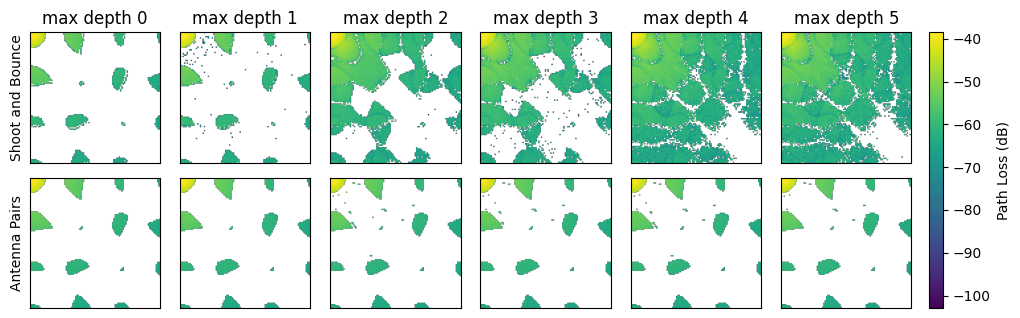

In [13]:
def path_gain_to_db(path_gain):
    path_gain = np.nanmean([path_gain[..., 0::2], path_gain[..., 1::2]], axis=0)
    # path_gain = (path_gain[..., 0::2] + path_gain[..., 1::2]) / 2
    return (10 * np.log10(path_gain)).reshape(-1, N-1, N-1)

def filter_valid(arr):
    return np.array(arr)[np.isfinite(np.array(arr))]

fig, axs = plt.subplots(ncols=len(max_depths), nrows=2, constrained_layout=True)
fig.get_layout_engine().set(w_pad=0.01, h_pad=0.01, hspace=0.1, wspace=0.1)
fig.set_size_inches(10, 3)
for ax in axs.flat:
    ax.set(xticks=[], yticks=[])
rms_raw = np.array(res["shoot_and_bounce"]).squeeze()
rms = path_gain_to_db(rms_raw)
rms_ref_raw = np.array(res["antenna_pairs"]).squeeze()
rms_ref = path_gain_to_db(rms_ref_raw)
norm = mpl.colors.Normalize(
    np.min(filter_valid([rms, rms_ref])), 
    np.max(filter_valid([rms, rms_ref])))
for i, max_depth in enumerate(max_depths):
    axs[0, i].imshow(rms[i], norm=norm)
    axs[1, i].imshow(rms_ref[i], norm=norm)
    axs[0, i].set_title(f"max depth {max_depth}")
axs[0, 0].set_ylabel("Shoot and Bounce")
axs[1, 0].set_ylabel("Antenna Pairs")
plt.colorbar(mpl.cm.ScalarMappable(norm), ax=axs, pad=0.02, label="Path Loss (dB)")